LOSS AVERSION ANALYSIS - JOB SCAMS SURVEY

SECTION 1: DATA LOADING

Dataset Shape: (96, 62)
Total Responses: 96

SECTION 2: PAYMENT BEHAVIOR

Payment Behavior:
  Total Respondents: 96
  Made Payment: 4 (4.2%)
  Did Not Pay: 92 (95.8%)

Payment Amount Statistics (payers only, n=4):
  Mean: ₹26875
  Median: ₹15625
  Range: ₹1250 - ₹75000
  Total lost: ₹107500

SECTION 3: LOSS AVERSION FACTORS EXTRACTION

Loss Aversion Indicators (among all respondents):
  Fear of losing opportunity: 7 (7.3%)
  Urgency/Time pressure: 4 (4.2%)
  Need for income: 2 (2.1%)

Loss Aversion Score (0-2):
loss_aversion_score
0    89
1     3
2     4
Name: count, dtype: int64
  Mean: 0.11
  Median: 0.0

SECTION 4: FINANCIAL VULNERABILITY

Vulnerability Score Distribution:
vulnerability_score
0    18
2    69
3     5
4     4
Name: count, dtype: int64

Statistics:
  Mean: 1.76
  Median: 2.0

HYPOTHESIS 1: FEAR OF LOSING OPPORTUNITY → PAYMENT

Contingency Table (Fear of Loss × Payment):
made_payment              0  1  

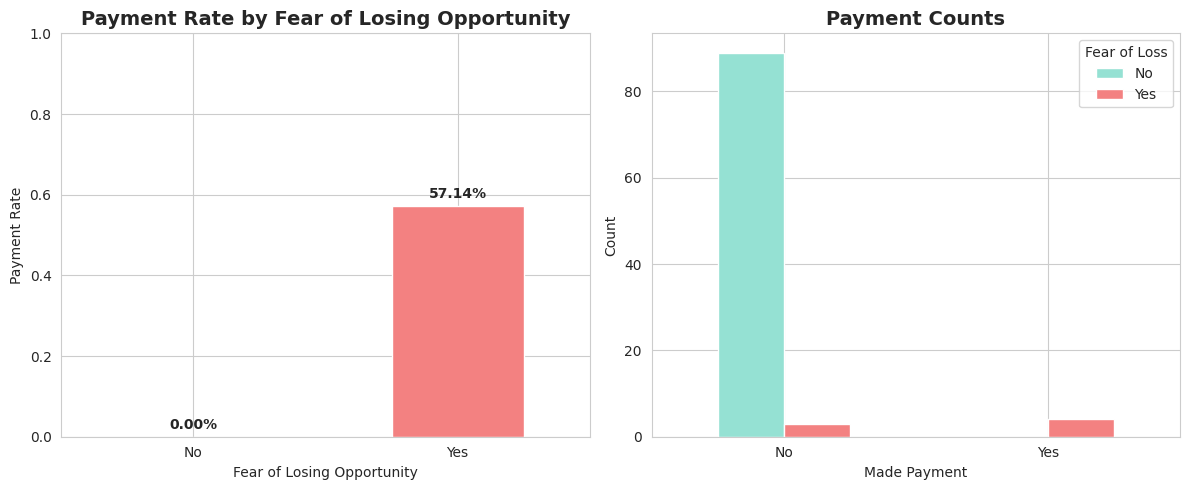


[VISUALIZATION] Fear of loss plot displayed

HYPOTHESIS 2: URGENCY/TIME PRESSURE → PAYMENT

Contingency Table (Urgency × Payment):
made_payment       0  1  All
urgency_pressure            
0                 91  1   92
1                  1  3    4
All               92  4   96

[TEST] Fisher's Exact Test:
  Odds Ratio = 273.0000
  p-value = 0.0001
  Significant at α=0.05? YES

[DESCRIPTIVE] Payment Rates by Urgency Pressure:
                  Payment_Rate   N  Paid
urgency_pressure                        
0                      0.01087  92     1
1                      0.75000   4     3


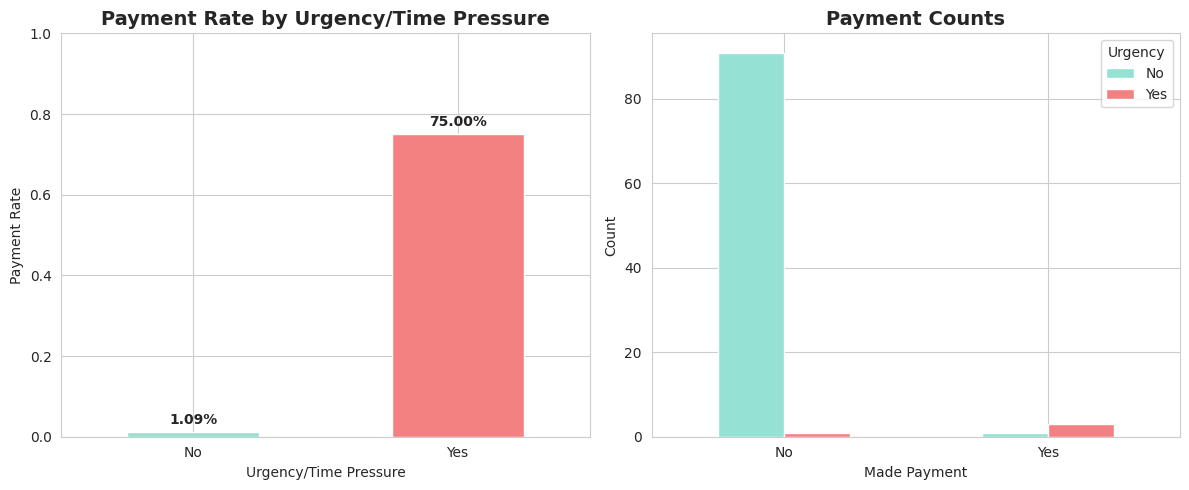


[VISUALIZATION] Urgency pressure plot displayed

HYPOTHESIS 3: VULNERABILITY × LOSS AVERSION → PAYMENT

Groups:
  High loss aversion: 7
  Low loss aversion: 89
  High vulnerability: 78
  Low vulnerability: 18

[DESCRIPTIVE] Vulnerability × Loss Aversion × Payment:
made_payment                            0  1  All
high_vulnerability high_loss_aversion            
0                  0                   18  0   18
1                  0                   71  0   71
                   1                    3  4    7
All                                    92  4   96

[DESCRIPTIVE] Payment Rates by Groups:
                                       Payment_Rate   N
high_vulnerability high_loss_aversion                  
0                  0                       0.000000  18
1                  0                       0.000000  71
                   1                       0.571429   7

[STRATIFIED ANALYSIS]:

  Low Vulnerability Group (n=18):
                    Payment_Rate   N
high_loss_aversion

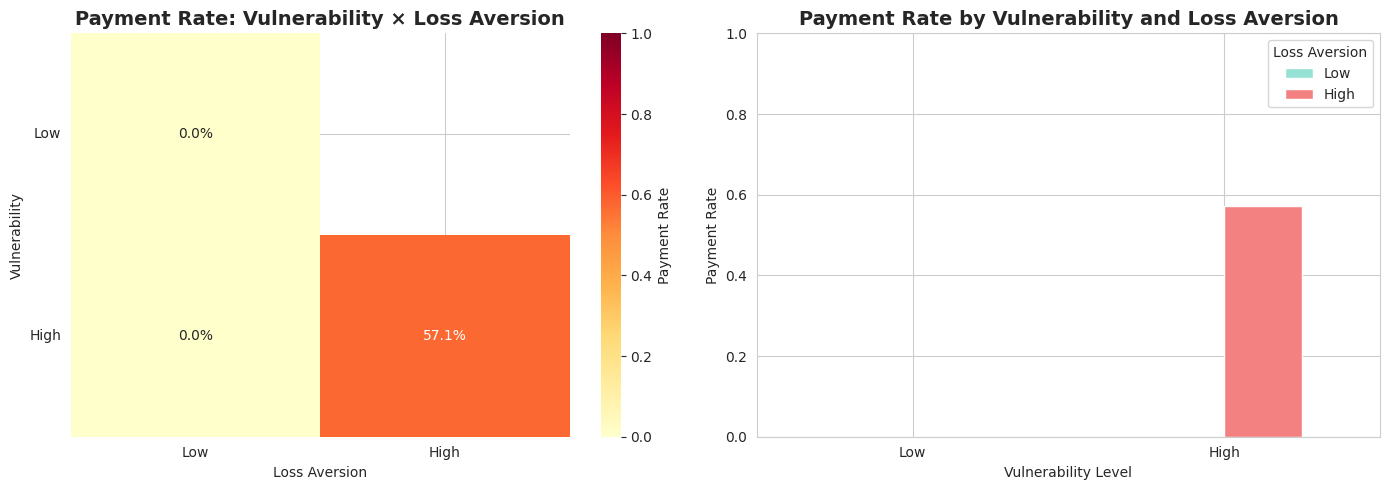


[VISUALIZATION] Interaction plot displayed

SECTION 8: SUNK COST EFFECT (TIME/EFFORT INVESTED)

Sunk Cost Influence Distribution (1-5 scale):
sunk_cost_influence
1.0    12
2.0    10
3.0    11
4.0     3
5.0     1
Name: count, dtype: int64

[TEST] Spearman Correlation (Sunk Cost × Payment):
  ρ = 0.3060
  p-value = 0.0655
  Significant at α=0.05? NO
  Interpretation: Positive correlation

[DESCRIPTIVE] Sunk Cost Influence by Payment Status:
                  mean  count
made_payment                 
0             2.121212     33
1             3.000000      4

[TEST] Mann-Whitney U Test:
  U-statistic = 102.0000
  p-value = 0.0702
  Significant at α=0.05? NO


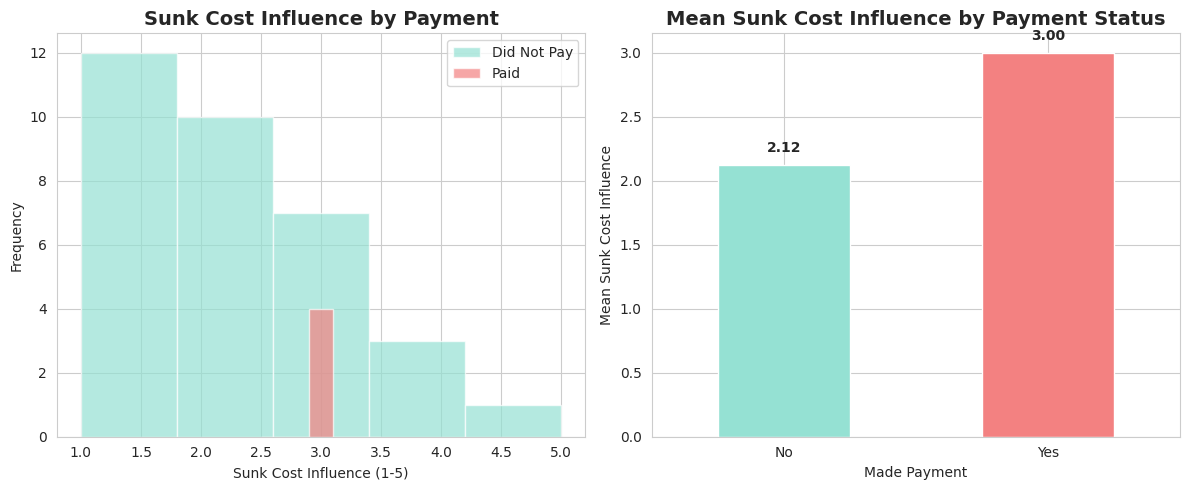


[VISUALIZATION] Sunk cost plot displayed

SECTION 9: VULNERABILITY × PAYMENT AMOUNT

Payment Amount Analysis (n=4 payers):

[NOTE] All payers have High vulnerability - cannot compare groups
Payment amount statistics:
  Mean: ₹26875
  Median: ₹15625
  Range: ₹1250 - ₹75000


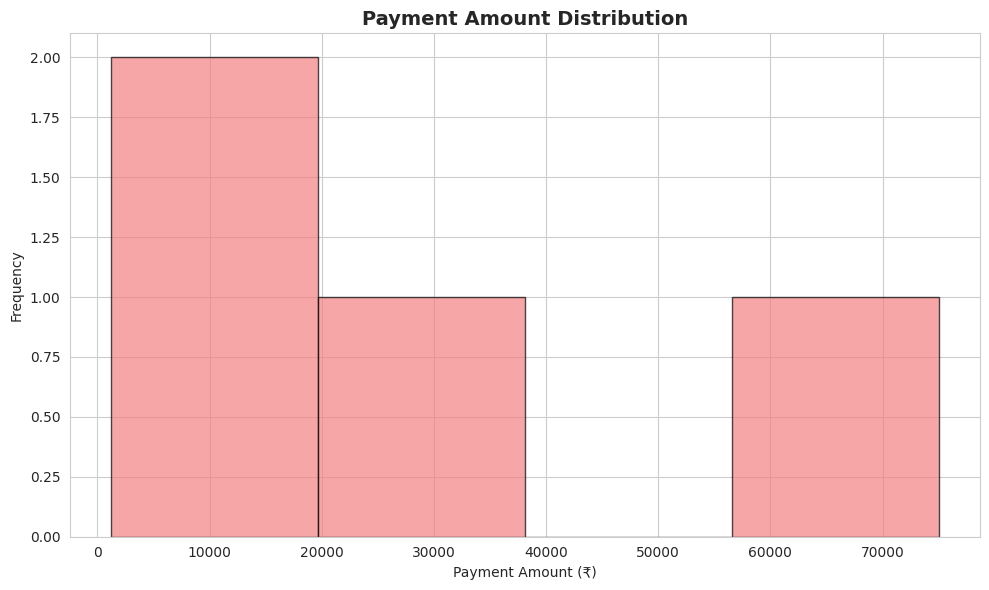


[VISUALIZATION] Payment amount histogram displayed

SECTION 10: LOGISTIC REGRESSION MODELS

Regression Dataset:
  Sample size: 37
  Payment rate: 10.81%

--------------------------------------------------------------------------------
MODEL 1: LOSS AVERSION FACTORS
--------------------------------------------------------------------------------

                              Results: Logit
Model:                  Logit               Pseudo R-squared:    0.672     
Dependent Variable:     made_payment        AIC:                 16.3178   
Date:                   2025-12-03 17:19    BIC:                 22.7615   
No. Observations:       37                  Log-Likelihood:      -4.1589   
Df Model:               3                   LL-Null:             -12.674   
Df Residuals:           33                  LLR p-value:         0.00069668
Converged:              1.0000              Scale:               1.0000    
Method:                 MLE                                               

In [1]:
"""
Loss Aversion Analysis for Job Scams Survey
Optimized for small datasets - ALL OUTPUT TO CONSOLE
Focus: Loss aversion effects without framing analysis
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, fisher_exact, mannwhitneyu, spearmanr
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

print("="*80)
print("LOSS AVERSION ANALYSIS - JOB SCAMS SURVEY")
print("="*80)

# ============================================================================
# SECTION 1: DATA LOADING
# ============================================================================

print("\n" + "="*80)
print("SECTION 1: DATA LOADING")
print("="*80)

df = pd.read_excel('responses.xlsx')
print(f"\nDataset Shape: {df.shape}")
print(f"Total Responses: {len(df)}")

# ============================================================================
# SECTION 2: PAYMENT BEHAVIOR EXTRACTION
# ============================================================================

print("\n" + "="*80)
print("SECTION 2: PAYMENT BEHAVIOR")
print("="*80)

# Payment amount
amount_col = 'Total amount paid (approx.)'
df['made_payment'] = df[amount_col].apply(
    lambda x: 0 if pd.isna(x) or 'I did not pay' in str(x) else 1
)

def amount_to_numeric(amount_str):
    if pd.isna(amount_str) or 'I did not pay' in str(amount_str) or 'Prefer not to say' in str(amount_str):
        return 0
    amount_str = str(amount_str)
    if 'Less than' in amount_str:
        return 250
    elif '₹500–₹1,999' in amount_str:
        return 1250
    elif '₹2,000–₹4,999' in amount_str:
        return 3500
    elif '₹5,000–₹9,999' in amount_str:
        return 7500
    elif '₹10,000–₹49,999' in amount_str:
        return 30000
    elif '₹50,000+' in amount_str:
        return 75000
    return 0

df['payment_amount'] = df[amount_col].apply(amount_to_numeric)

print(f"\nPayment Behavior:")
print(f"  Total Respondents: {len(df)}")
print(f"  Made Payment: {df['made_payment'].sum()} ({df['made_payment'].mean()*100:.1f}%)")
print(f"  Did Not Pay: {(1-df['made_payment']).sum()} ({(1-df['made_payment']).mean()*100:.1f}%)")

# Don't create payers dataframe yet - wait until after vulnerability is calculated
if df['made_payment'].sum() > 0:
    payers_temp = df[df['made_payment']==1]
    print(f"\nPayment Amount Statistics (payers only, n={len(payers_temp)}):")
    print(f"  Mean: ₹{payers_temp['payment_amount'].mean():.0f}")
    print(f"  Median: ₹{payers_temp['payment_amount'].median():.0f}")
    print(f"  Range: ₹{payers_temp['payment_amount'].min():.0f} - ₹{payers_temp['payment_amount'].max():.0f}")
    print(f"  Total lost: ₹{payers_temp['payment_amount'].sum():.0f}")

# ============================================================================
# SECTION 3: LOSS AVERSION FACTORS
# ============================================================================

print("\n" + "="*80)
print("SECTION 3: LOSS AVERSION FACTORS EXTRACTION")
print("="*80)

# Key loss aversion variables from payment reasons
payment_reasons_col = 'What affected you to pay at the time? (only if applied, select all top reasons)'

df['fear_losing_opportunity'] = df[payment_reasons_col].apply(
    lambda x: 1 if pd.notna(x) and 'Fear of losing opportunity' in str(x) else 0
)
df['urgency_pressure'] = df[payment_reasons_col].apply(
    lambda x: 1 if pd.notna(x) and 'Sense of urgency or time pressure' in str(x) else 0
)
df['need_for_income'] = df[payment_reasons_col].apply(
    lambda x: 1 if pd.notna(x) and 'Need for income' in str(x) else 0
)

print("\nLoss Aversion Indicators (among all respondents):")
print(f"  Fear of losing opportunity: {df['fear_losing_opportunity'].sum()} ({df['fear_losing_opportunity'].mean()*100:.1f}%)")
print(f"  Urgency/Time pressure: {df['urgency_pressure'].sum()} ({df['urgency_pressure'].mean()*100:.1f}%)")
print(f"  Need for income: {df['need_for_income'].sum()} ({df['need_for_income'].mean()*100:.1f}%)")

# Combined loss aversion score
df['loss_aversion_score'] = (
    df['fear_losing_opportunity'] +
    df['urgency_pressure']
)

print(f"\nLoss Aversion Score (0-2):")
print(df['loss_aversion_score'].value_counts().sort_index())
print(f"  Mean: {df['loss_aversion_score'].mean():.2f}")
print(f"  Median: {df['loss_aversion_score'].median():.1f}")

# ============================================================================
# SECTION 4: VULNERABILITY SCORING
# ============================================================================

print("\n" + "="*80)
print("SECTION 4: FINANCIAL VULNERABILITY")
print("="*80)

income_col = 'Current monthly personal income (approx.)'
household_col = 'Household financial situation'

vulnerability_score = pd.Series(0, index=df.index)

df['low_income'] = df[income_col].apply(
    lambda x: 1 if pd.notna(x) and any(term in str(x) for term in ['Less than', '₹10k–20k', 'Not applicable']) else 0
)
vulnerability_score += df['low_income'] * 2

df['financial_stress'] = df[household_col].apply(
    lambda x: 2 if pd.notna(x) and 'Struggling' in str(x)
    else 1 if pd.notna(x) and 'In debt' in str(x)
    else 0
)
vulnerability_score += df['financial_stress']

df['vulnerability_score'] = vulnerability_score

print(f"\nVulnerability Score Distribution:")
print(df['vulnerability_score'].value_counts().sort_index())
print(f"\nStatistics:")
print(f"  Mean: {df['vulnerability_score'].mean():.2f}")
print(f"  Median: {df['vulnerability_score'].median():.1f}")

# Create binary groups for analysis
df['high_vulnerability'] = (df['vulnerability_score'] >= df['vulnerability_score'].median()).astype(int)

# NOW create payers dataframe (after all columns are ready)
payers = df[df['made_payment']==1].copy()

# ============================================================================
# SECTION 5: HYPOTHESIS - FEAR OF LOSS × PAYMENT BEHAVIOR
# ============================================================================

print("\n" + "="*80)
print("HYPOTHESIS 1: FEAR OF LOSING OPPORTUNITY → PAYMENT")
print("="*80)

# Contingency table
fear_contingency = pd.crosstab(df['fear_losing_opportunity'], df['made_payment'], margins=True)
print("\nContingency Table (Fear of Loss × Payment):")
print(fear_contingency)

# Fisher's Exact Test (best for small samples)
fear_cont_no_margin = pd.crosstab(df['fear_losing_opportunity'], df['made_payment'])
if fear_cont_no_margin.shape == (2, 2):
    oddsratio, p_fisher = fisher_exact(fear_cont_no_margin)
    print(f"\n[TEST] Fisher's Exact Test:")
    print(f"  Odds Ratio = {oddsratio:.4f}")
    print(f"  p-value = {p_fisher:.4f}")
    print(f"  Significant at α=0.05? {'YES' if p_fisher < 0.05 else 'NO'}")
    print(f"\n  Interpretation: Those with fear of loss have {oddsratio:.2f}x odds of paying")

# Payment rates
fear_payment = df.groupby('fear_losing_opportunity')['made_payment'].agg([
    ('Payment_Rate', 'mean'),
    ('N', 'count'),
    ('Paid', 'sum')
])
print("\n[DESCRIPTIVE] Payment Rates by Fear of Loss:")
print(fear_payment)

# Effect size
if 0 in fear_payment.index and 1 in fear_payment.index:
    p0 = fear_payment.loc[0, 'Payment_Rate']
    p1 = fear_payment.loc[1, 'Payment_Rate']
    if p0 > 0 and p1 > 0:
        cohens_h = 2 * (np.arcsin(np.sqrt(p1)) - np.arcsin(np.sqrt(p0)))
        print(f"\n[EFFECT SIZE] Cohen's h = {cohens_h:.4f}")
        print(f"  Magnitude: ", end="")
        if abs(cohens_h) < 0.2:
            print("Small")
        elif abs(cohens_h) < 0.5:
            print("Medium")
        else:
            print("Large")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

if len(fear_payment) == 2:
    fear_payment['Payment_Rate'].plot(kind='bar', ax=axes[0], color=['#95E1D3', '#F38181'])
    axes[0].set_title('Payment Rate by Fear of Losing Opportunity', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Payment Rate')
    axes[0].set_xlabel('Fear of Losing Opportunity')
    axes[0].set_xticklabels(['No', 'Yes'], rotation=0)
    axes[0].set_ylim([0, 1])
    for i, (idx, row) in enumerate(fear_payment.iterrows()):
        v = row['Payment_Rate']
        axes[0].text(i, v + 0.02, f'{v:.2%}', ha='center', fontweight='bold')

fear_cont_no_margin.T.plot(kind='bar', ax=axes[1], color=['#95E1D3', '#F38181'])
axes[1].set_title('Payment Counts', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].set_xlabel('Made Payment')
axes[1].set_xticklabels(['No', 'Yes'], rotation=0)
axes[1].legend(title='Fear of Loss', labels=['No', 'Yes'])

plt.tight_layout()
plt.show()
print("\n[VISUALIZATION] Fear of loss plot displayed")

# ============================================================================
# SECTION 6: HYPOTHESIS - TIME PRESSURE × PAYMENT
# ============================================================================

print("\n" + "="*80)
print("HYPOTHESIS 2: URGENCY/TIME PRESSURE → PAYMENT")
print("="*80)

urgency_contingency = pd.crosstab(df['urgency_pressure'], df['made_payment'], margins=True)
print("\nContingency Table (Urgency × Payment):")
print(urgency_contingency)

urgency_cont_no_margin = pd.crosstab(df['urgency_pressure'], df['made_payment'])
if urgency_cont_no_margin.shape == (2, 2):
    oddsratio_urg, p_fisher_urg = fisher_exact(urgency_cont_no_margin)
    print(f"\n[TEST] Fisher's Exact Test:")
    print(f"  Odds Ratio = {oddsratio_urg:.4f}")
    print(f"  p-value = {p_fisher_urg:.4f}")
    print(f"  Significant at α=0.05? {'YES' if p_fisher_urg < 0.05 else 'NO'}")

urgency_payment = df.groupby('urgency_pressure')['made_payment'].agg([
    ('Payment_Rate', 'mean'),
    ('N', 'count'),
    ('Paid', 'sum')
])
print("\n[DESCRIPTIVE] Payment Rates by Urgency Pressure:")
print(urgency_payment)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

if len(urgency_payment) == 2:
    urgency_payment['Payment_Rate'].plot(kind='bar', ax=axes[0], color=['#95E1D3', '#F38181'])
    axes[0].set_title('Payment Rate by Urgency/Time Pressure', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Payment Rate')
    axes[0].set_xlabel('Urgency/Time Pressure')
    axes[0].set_xticklabels(['No', 'Yes'], rotation=0)
    axes[0].set_ylim([0, 1])
    for i, (idx, row) in enumerate(urgency_payment.iterrows()):
        v = row['Payment_Rate']
        axes[0].text(i, v + 0.02, f'{v:.2%}', ha='center', fontweight='bold')

urgency_cont_no_margin.T.plot(kind='bar', ax=axes[1], color=['#95E1D3', '#F38181'])
axes[1].set_title('Payment Counts', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].set_xlabel('Made Payment')
axes[1].set_xticklabels(['No', 'Yes'], rotation=0)
axes[1].legend(title='Urgency', labels=['No', 'Yes'])

plt.tight_layout()
plt.show()
print("\n[VISUALIZATION] Urgency pressure plot displayed")

# ============================================================================
# SECTION 7: HYPOTHESIS - VULNERABILITY MODERATES LOSS AVERSION
# ============================================================================

print("\n" + "="*80)
print("HYPOTHESIS 3: VULNERABILITY × LOSS AVERSION → PAYMENT")
print("="*80)

# Create loss aversion binary variable
df['high_loss_aversion'] = (df['loss_aversion_score'] >= 1).astype(int)

print(f"\nGroups:")
print(f"  High loss aversion: {df['high_loss_aversion'].sum()}")
print(f"  Low loss aversion: {(1-df['high_loss_aversion']).sum()}")
print(f"  High vulnerability: {df['high_vulnerability'].sum()}")
print(f"  Low vulnerability: {(1-df['high_vulnerability']).sum()}")

# Cross-tabulation
cross_tab = pd.crosstab(
    [df['high_vulnerability'], df['high_loss_aversion']],
    df['made_payment'],
    margins=True
)
print("\n[DESCRIPTIVE] Vulnerability × Loss Aversion × Payment:")
print(cross_tab)

# Payment rates by groups
interaction_stats = df.groupby(['high_vulnerability', 'high_loss_aversion'])['made_payment'].agg([
    ('Payment_Rate', 'mean'),
    ('N', 'count')
])
print("\n[DESCRIPTIVE] Payment Rates by Groups:")
print(interaction_stats)

# Stratified analysis
print("\n[STRATIFIED ANALYSIS]:")
for vuln in [0, 1]:
    vuln_data = df[df['high_vulnerability']==vuln]
    if len(vuln_data) > 0:
        print(f"\n  {'High' if vuln else 'Low'} Vulnerability Group (n={len(vuln_data)}):")
        stratified = vuln_data.groupby('high_loss_aversion')['made_payment'].agg([
            ('Payment_Rate', 'mean'),
            ('N', 'count')
        ])
        print(stratified)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pivot_table = df.pivot_table(
    values='made_payment',
    index='high_vulnerability',
    columns='high_loss_aversion',
    aggfunc='mean'
)

if not pivot_table.empty and pivot_table.shape == (2, 2):
    sns.heatmap(pivot_table, annot=True, fmt='.1%', cmap='YlOrRd', ax=axes[0],
                cbar_kws={'label': 'Payment Rate'}, vmin=0, vmax=1)
    axes[0].set_title('Payment Rate: Vulnerability × Loss Aversion', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Vulnerability')
    axes[0].set_xlabel('Loss Aversion')
    axes[0].set_yticklabels(['Low', 'High'], rotation=0)
    axes[0].set_xticklabels(['Low', 'High'], rotation=0)

if len(interaction_stats) > 0:
    interaction_unstacked = interaction_stats['Payment_Rate'].unstack(fill_value=0)
    if not interaction_unstacked.empty:
        interaction_unstacked.plot(kind='bar', ax=axes[1], color=['#95E1D3', '#F38181'])
        axes[1].set_title('Payment Rate by Vulnerability and Loss Aversion', fontsize=14, fontweight='bold')
        axes[1].set_ylabel('Payment Rate')
        axes[1].set_xlabel('Vulnerability Level')
        axes[1].set_xticklabels(['Low', 'High'], rotation=0)
        axes[1].legend(title='Loss Aversion', labels=['Low', 'High'])
        axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()
print("\n[VISUALIZATION] Interaction plot displayed")

# ============================================================================
# SECTION 8: SUNK COST EFFECT
# ============================================================================

print("\n" + "="*80)
print("SECTION 8: SUNK COST EFFECT (TIME/EFFORT INVESTED)")
print("="*80)

sunk_cost_col = 'How much did the time and effort you had already invested influence your decision to continue?'
df['sunk_cost_influence'] = df[sunk_cost_col]

print(f"\nSunk Cost Influence Distribution (1-5 scale):")
print(df['sunk_cost_influence'].value_counts().sort_index())

# Correlation with payment
valid_sunk = df['sunk_cost_influence'].notna()
if df[valid_sunk]['sunk_cost_influence'].nunique() > 1 and df[valid_sunk]['made_payment'].sum() > 0:
    corr_sunk, p_sunk = spearmanr(
        df.loc[valid_sunk, 'sunk_cost_influence'],
        df.loc[valid_sunk, 'made_payment']
    )
    print(f"\n[TEST] Spearman Correlation (Sunk Cost × Payment):")
    print(f"  ρ = {corr_sunk:.4f}")
    print(f"  p-value = {p_sunk:.4f}")
    print(f"  Significant at α=0.05? {'YES' if p_sunk < 0.05 else 'NO'}")
    print(f"  Interpretation: {'Positive' if corr_sunk > 0 else 'Negative'} correlation")

# Group by payment status
sunk_by_payment = df.groupby('made_payment')['sunk_cost_influence'].agg(['mean', 'count'])
print(f"\n[DESCRIPTIVE] Sunk Cost Influence by Payment Status:")
print(sunk_by_payment)

# Mann-Whitney U test
if df['made_payment'].sum() > 0:
    payers_sunk = df[df['made_payment']==1]['sunk_cost_influence'].dropna()
    nonpayers_sunk = df[df['made_payment']==0]['sunk_cost_influence'].dropna()

    if len(payers_sunk) > 0 and len(nonpayers_sunk) > 0:
        u_stat, p_mann = mannwhitneyu(payers_sunk, nonpayers_sunk, alternative='two-sided')
        print(f"\n[TEST] Mann-Whitney U Test:")
        print(f"  U-statistic = {u_stat:.4f}")
        print(f"  p-value = {p_mann:.4f}")
        print(f"  Significant at α=0.05? {'YES' if p_mann < 0.05 else 'NO'}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df[df['made_payment']==0]['sunk_cost_influence'].hist(ax=axes[0], bins=5, alpha=0.7,
                                                        label='Did Not Pay', color='#95E1D3')
df[df['made_payment']==1]['sunk_cost_influence'].hist(ax=axes[0], bins=5, alpha=0.7,
                                                        label='Paid', color='#F38181')
axes[0].set_title('Sunk Cost Influence by Payment', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sunk Cost Influence (1-5)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

if len(sunk_by_payment) > 1:
    sunk_by_payment['mean'].plot(kind='bar', ax=axes[1], color=['#95E1D3', '#F38181'])
    axes[1].set_title('Mean Sunk Cost Influence by Payment Status', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Mean Sunk Cost Influence')
    axes[1].set_xlabel('Made Payment')
    axes[1].set_xticklabels(['No', 'Yes'], rotation=0)
    for i, (idx, row) in enumerate(sunk_by_payment.iterrows()):
        v = row['mean']
        axes[1].text(i, v + 0.1, f'{v:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()
print("\n[VISUALIZATION] Sunk cost plot displayed")

# ============================================================================
# SECTION 9: FINANCIAL VULNERABILITY × PAYMENT AMOUNT
# ============================================================================

print("\n" + "="*80)
print("SECTION 9: VULNERABILITY × PAYMENT AMOUNT")
print("="*80)

if len(payers) > 0:
    print(f"\nPayment Amount Analysis (n={len(payers)} payers):")

    # Check if we have vulnerability variation among payers
    if payers['high_vulnerability'].nunique() > 1:
        vuln_payment_amt = payers.groupby('high_vulnerability')['payment_amount'].agg([
            ('Mean', 'mean'),
            ('Median', 'median'),
            ('N', 'count')
        ])
        print("\n[DESCRIPTIVE] Payment Amount by Vulnerability:")
        print(vuln_payment_amt)

        # Test if vulnerability groups differ in payment amount
        low_vuln_amt = payers[payers['high_vulnerability']==0]['payment_amount']
        high_vuln_amt = payers[payers['high_vulnerability']==1]['payment_amount']

        if len(low_vuln_amt) > 0 and len(high_vuln_amt) > 0:
            u_stat_amt, p_amt = mannwhitneyu(low_vuln_amt, high_vuln_amt, alternative='two-sided')
            print(f"\n[TEST] Mann-Whitney U Test (Amount × Vulnerability):")
            print(f"  U = {u_stat_amt:.4f}")
            print(f"  p-value = {p_amt:.4f}")
            print(f"  Significant at α=0.05? {'YES' if p_amt < 0.05 else 'NO'}")

        # Visualization
        fig, ax = plt.subplots(1, 1, figsize=(10, 6))

        payers.boxplot(column='payment_amount', by='high_vulnerability', ax=ax)
        ax.set_title('Payment Amount by Vulnerability Level', fontsize=14, fontweight='bold')
        ax.set_xlabel('Vulnerability Level')
        ax.set_ylabel('Payment Amount (₹)')
        ax.set_xticklabels(['Low', 'High'])
        plt.suptitle('')

        plt.tight_layout()
        plt.show()
        print("\n[VISUALIZATION] Payment amount plot displayed")

    else:
        vuln_level = 'High' if payers['high_vulnerability'].iloc[0] == 1 else 'Low'
        print(f"\n[NOTE] All payers have {vuln_level} vulnerability - cannot compare groups")
        print(f"Payment amount statistics:")
        print(f"  Mean: ₹{payers['payment_amount'].mean():.0f}")
        print(f"  Median: ₹{payers['payment_amount'].median():.0f}")
        print(f"  Range: ₹{payers['payment_amount'].min():.0f} - ₹{payers['payment_amount'].max():.0f}")

        # Simple histogram
        fig, ax = plt.subplots(1, 1, figsize=(10, 6))
        ax.hist(payers['payment_amount'], bins=min(5, len(payers)), color='#F38181', alpha=0.7, edgecolor='black')
        ax.set_title('Payment Amount Distribution', fontsize=14, fontweight='bold')
        ax.set_xlabel('Payment Amount (₹)')
        ax.set_ylabel('Frequency')

        plt.tight_layout()
        plt.show()
        print("\n[VISUALIZATION] Payment amount histogram displayed")

else:
    print("\nNo payers in dataset - skipping payment amount analysis")

# ============================================================================
# SECTION 10: LOGISTIC REGRESSION MODELS
# ============================================================================

print("\n" + "="*80)
print("SECTION 10: LOGISTIC REGRESSION MODELS")
print("="*80)

# Prepare regression data
regression_df = df[[
    'made_payment',
    'vulnerability_score',
    'fear_losing_opportunity',
    'urgency_pressure',
    'need_for_income',
    'sunk_cost_influence'
]].copy()

regression_df = regression_df.dropna()

print(f"\nRegression Dataset:")
print(f"  Sample size: {len(regression_df)}")
print(f"  Payment rate: {regression_df['made_payment'].mean():.2%}")

if len(regression_df) >= 10 and regression_df['made_payment'].sum() > 0:

    # Model 1: Loss Aversion Factors Only
    print("\n" + "-"*80)
    print("MODEL 1: LOSS AVERSION FACTORS")
    print("-"*80)

    X1 = regression_df[['fear_losing_opportunity', 'urgency_pressure', 'sunk_cost_influence']]
    y = regression_df['made_payment']
    X1_const = sm.add_constant(X1)

    try:
        model1 = sm.Logit(y, X1_const).fit(method='bfgs', maxiter=100, disp=0)
        print("\n" + str(model1.summary2()))

        print("\n" + "="*60)
        print("ODDS RATIOS:")
        print("="*60)
        odds_df1 = pd.DataFrame({
            'Variable': model1.params.index,
            'Coefficient': model1.params.values,
            'Odds Ratio': np.exp(model1.params.values),
            'p-value': model1.pvalues.values,
            'Sig': ['***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
                   for p in model1.pvalues.values]
        })
        print(odds_df1.to_string(index=False))
    except Exception as e:
        print(f"Model 1 failed: {e}")

    # Model 2: With Vulnerability
    print("\n" + "-"*80)
    print("MODEL 2: LOSS AVERSION + VULNERABILITY")
    print("-"*80)

    X2 = regression_df[['vulnerability_score', 'fear_losing_opportunity', 'urgency_pressure', 'sunk_cost_influence']]
    X2_const = sm.add_constant(X2)

    try:
        model2 = sm.Logit(y, X2_const).fit(method='bfgs', maxiter=100, disp=0)
        print("\n" + str(model2.summary2()))

        print("\n" + "="*60)
        print("ODDS RATIOS:")
        print("="*60)
        odds_df2 = pd.DataFrame({
            'Variable': model2.params.index,
            'Coefficient': model2.params.values,
            'Odds Ratio': np.exp(model2.params.values),
            'p-value': model2.pvalues.values,
            'Sig': ['***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
                   for p in model2.pvalues.values]
        })
        print(odds_df2.to_string(index=False))
    except Exception as e:
        print(f"Model 2 failed: {e}")

    # Model 3: Interaction Effect
    print("\n" + "-"*80)
    print("MODEL 3: VULNERABILITY × FEAR OF LOSS INTERACTION")
    print("-"*80)

    regression_df['vuln_x_fear'] = regression_df['vulnerability_score'] * regression_df['fear_losing_opportunity']
    X3 = regression_df[['vulnerability_score', 'fear_losing_opportunity', 'vuln_x_fear', 'sunk_cost_influence']]
    X3_const = sm.add_constant(X3)

    try:
        model3 = sm.Logit(y, X3_const).fit(method='bfgs', maxiter=100, disp=0)
        print("\n" + str(model3.summary2()))

        print("\n" + "="*60)
        print("ODDS RATIOS:")
        print("="*60)
        print("Note: Significant interaction means vulnerability modifies fear of loss effect")
        print("="*60)
        odds_df3 = pd.DataFrame({
            'Variable': model3.params.index,
            'Coefficient': model3.params.values,
            'Odds Ratio': np.exp(model3.params.values),
            'p-value': model3.pvalues.values,
            'Sig': ['***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
                   for p in model3.pvalues.values]
        })
        print(odds_df3.to_string(index=False))
    except Exception as e:
        print(f"Model 3 failed: {e}")

else:
    print(f"\nInsufficient data for regression (n={len(regression_df)}, payers={regression_df['made_payment'].sum()})")

# ============================================================================
# SECTION 11: SUMMARY STATISTICS TABLE
# ============================================================================

print("\n" + "="*80)
print("SECTION 11: SUMMARY STATISTICS")
print("="*80)

summary_data = {
    'Metric': [
        'Payment Rate',
        'Mean Vulnerability',
        'Fear of Loss (%)',
        'Urgency Pressure (%)',
        'Mean Sunk Cost Influence',
        'Mean Payment Amount (payers)'
    ],
    'Overall': [
        f"{df['made_payment'].mean():.1%}",
        f"{df['vulnerability_score'].mean():.2f}",
        f"{df['fear_losing_opportunity'].mean():.1%}",
        f"{df['urgency_pressure'].mean():.1%}",
        f"{df['sunk_cost_influence'].mean():.2f}",
        f"₹{payers['payment_amount'].mean():.0f}" if len(payers) > 0 else "N/A"
    ],
    'Low_Vulnerability': [],
    'High_Vulnerability': []
}

# Add vulnerability group stats
low_vuln = df[df['high_vulnerability']==0]
high_vuln = df[df['high_vulnerability']==1]

summary_data['Low_Vulnerability'] = [
    f"{low_vuln['made_payment'].mean():.1%}" if len(low_vuln) > 0 else "N/A",
    f"{low_vuln['vulnerability_score'].mean():.2f}" if len(low_vuln) > 0 else "N/A",
    f"{low_vuln['fear_losing_opportunity'].mean():.1%}" if len(low_vuln) > 0 else "N/A",
    f"{low_vuln['urgency_pressure'].mean():.1%}" if len(low_vuln) > 0 else "N/A",
    f"{low_vuln['sunk_cost_influence'].mean():.2f}" if len(low_vuln) > 0 else "N/A",
    f"₹{payers[payers['high_vulnerability']==0]['payment_amount'].mean():.0f}" if len(payers[payers['high_vulnerability']==0]) > 0 else "N/A"
]

summary_data['High_Vulnerability'] = [
    f"{high_vuln['made_payment'].mean():.1%}" if len(high_vuln) > 0 else "N/A",
    f"{high_vuln['vulnerability_score'].mean():.2f}" if len(high_vuln) > 0 else "N/A",
    f"{high_vuln['fear_losing_opportunity'].mean():.1%}" if len(high_vuln) > 0 else "N/A",
    f"{high_vuln['urgency_pressure'].mean():.1%}" if len(high_vuln) > 0 else "N/A",
    f"{high_vuln['sunk_cost_influence'].mean():.2f}" if len(high_vuln) > 0 else "N/A",
    f"₹{payers[payers['high_vulnerability']==1]['payment_amount'].mean():.0f}" if len(payers[payers['high_vulnerability']==1]) > 0 else "N/A"
]

summary_table = pd.DataFrame(summary_data)
print("\n" + "="*80)
print("SUMMARY STATISTICS TABLE")
print("="*80)
print(summary_table.to_string(index=False))

# ============================================================================
# SECTION 12: HYPOTHESIS TESTING RESULTS
# ============================================================================

print("\n" + "="*80)
print("SECTION 12: HYPOTHESIS TESTING RESULTS SUMMARY")
print("="*80)

results_data = []

# H1: Fear of Loss
if 0 in fear_payment.index and 1 in fear_payment.index:
    no_fear_rate = fear_payment.loc[0, 'Payment_Rate']
    fear_rate = fear_payment.loc[1, 'Payment_Rate']
    results_data.append({
        'Hypothesis': 'H1: Fear of Loss → Payment',
        'Finding': f"No fear: {no_fear_rate:.1%} vs Fear: {fear_rate:.1%}",
        'Test': 'Fisher Exact',
        'N': len(df),
        'Direction': 'Higher' if fear_rate > no_fear_rate else 'Lower'
    })

# H2: Urgency Pressure
if 0 in urgency_payment.index and 1 in urgency_payment.index:
    no_urg_rate = urgency_payment.loc[0, 'Payment_Rate']
    urg_rate = urgency_payment.loc[1, 'Payment_Rate']
    results_data.append({
        'Hypothesis': 'H2: Urgency Pressure → Payment',
        'Finding': f"No urgency: {no_urg_rate:.1%} vs Urgency: {urg_rate:.1%}",
        'Test': 'Fisher Exact',
        'N': len(df),
        'Direction': 'Higher' if urg_rate > no_urg_rate else 'Lower'
    })

# H3: Vulnerability × Loss Aversion
if len(interaction_stats) > 0:
    min_rate = interaction_stats['Payment_Rate'].min()
    max_rate = interaction_stats['Payment_Rate'].max()
    results_data.append({
        'Hypothesis': 'H3: Vulnerability × Loss Aversion',
        'Finding': f"Payment rate range: {min_rate:.1%} - {max_rate:.1%}",
        'Test': 'Stratified Analysis',
        'N': len(df),
        'Direction': 'Interaction' if max_rate - min_rate > 0.1 else 'Weak'
    })

# H4: Sunk Cost
if len(sunk_by_payment) > 1:
    nonpayer_sunk = sunk_by_payment.loc[0, 'mean']
    payer_sunk = sunk_by_payment.loc[1, 'mean']
    results_data.append({
        'Hypothesis': 'H4: Sunk Cost → Payment',
        'Finding': f"Non-payers: {nonpayer_sunk:.2f} vs Payers: {payer_sunk:.2f}",
        'Test': 'Mann-Whitney U',
        'N': int(sunk_by_payment['count'].sum()),
        'Direction': 'Higher' if payer_sunk > nonpayer_sunk else 'Lower'
    })

if len(results_data) > 0:
    results_table = pd.DataFrame(results_data)
    print("\n" + results_table.to_string(index=False))
else:
    print("\nInsufficient data for hypothesis testing")

# ============================================================================
# SECTION 13: EFFECT SIZE SUMMARY
# ============================================================================

print("\n" + "="*80)
print("SECTION 13: EFFECT SIZES & PRACTICAL SIGNIFICANCE")
print("="*80)

effect_sizes = []

# Fear of loss effect
if 0 in fear_payment.index and 1 in fear_payment.index:
    p0 = fear_payment.loc[0, 'Payment_Rate']
    p1 = fear_payment.loc[1, 'Payment_Rate']
    if p0 > 0 and p1 > 0 and p0 < 1 and p1 < 1:
        h = 2 * (np.arcsin(np.sqrt(p1)) - np.arcsin(np.sqrt(p0)))
        magnitude = "Small" if abs(h) < 0.2 else "Medium" if abs(h) < 0.5 else "Large"
        effect_sizes.append({
            'Factor': 'Fear of Losing Opportunity',
            'Effect_Size_h': f"{h:.3f}",
            'Magnitude': magnitude,
            'Percentage_Point_Diff': f"{(p1-p0)*100:.1f}pp"
        })

# Urgency effect
if 0 in urgency_payment.index and 1 in urgency_payment.index:
    p0 = urgency_payment.loc[0, 'Payment_Rate']
    p1 = urgency_payment.loc[1, 'Payment_Rate']
    if p0 > 0 and p1 > 0 and p0 < 1 and p1 < 1:
        h = 2 * (np.arcsin(np.sqrt(p1)) - np.arcsin(np.sqrt(p0)))
        magnitude = "Small" if abs(h) < 0.2 else "Medium" if abs(h) < 0.5 else "Large"
        effect_sizes.append({
            'Factor': 'Urgency/Time Pressure',
            'Effect_Size_h': f"{h:.3f}",
            'Magnitude': magnitude,
            'Percentage_Point_Diff': f"{(p1-p0)*100:.1f}pp"
        })

if len(effect_sizes) > 0:
    effect_table = pd.DataFrame(effect_sizes)
    print("\n" + effect_table.to_string(index=False))
    print("\nNote: Cohen's h interpretation - 0.2=small, 0.5=medium, 0.8=large")
else:
    print("\nInsufficient data for effect size calculation")

# ============================================================================
# FINAL SUMMARY
# ============================================================================

print("\n" + "="*80)
print("LOSS AVERSION ANALYSIS COMPLETE")
print("="*80)

print("\n" + "="*60)
print("KEY FINDINGS:")
print("="*60)

print(f"\n1. OVERALL PAYMENT BEHAVIOR")
print(f"   • Payment rate: {df['made_payment'].mean():.1%}")
print(f"   • Number of payers: {df['made_payment'].sum()}")
print(f"   • Mean payment amount: ₹{payers['payment_amount'].mean():,.0f}" if len(payers) > 0 else "   • No payers in dataset")

print(f"\n2. LOSS AVERSION INDICATORS")
print(f"   • Fear of losing opportunity: {df['fear_losing_opportunity'].sum()} respondents ({df['fear_losing_opportunity'].mean():.1%})")
print(f"   • Urgency/time pressure: {df['urgency_pressure'].sum()} respondents ({df['urgency_pressure'].mean():.1%})")
print(f"   • Mean sunk cost influence: {df['sunk_cost_influence'].mean():.2f}/5")

print(f"\n3. VULNERABILITY")
print(f"   • Mean vulnerability score: {df['vulnerability_score'].mean():.2f}")
print(f"   • High vulnerability: {df['high_vulnerability'].sum()} respondents")
print(f"   • Low vulnerability: {(1-df['high_vulnerability']).sum()} respondents")

if len(results_data) > 0:
    print(f"\n4. HYPOTHESIS TESTS")
    for result in results_data:
        print(f"   • {result['Hypothesis']}: {result['Direction']}")

print("\n" + "="*60)
print("STATISTICAL METHODS USED:")
print("="*60)
print("  ✓ Fisher's Exact Test (categorical associations, small samples)")
print("  ✓ Mann-Whitney U Test (non-parametric continuous comparisons)")
print("  ✓ Spearman Correlation (ordinal relationships)")
print("  ✓ Logistic Regression (multivariate analysis)")
print("  ✓ Effect Sizes (Cohen's h for practical significance)")
print("  ✓ Stratified Analysis (interaction effects)")

print("\n" + "="*60)
print("LIMITATIONS:")
print("="*60)
print(f"  • Small sample size (n={len(df)})")
print(f"  • Low payment rate ({df['made_payment'].mean():.1%})")
print(f"  • Limited statistical power for detecting small effects")
print(f"  • Results should be interpreted with caution")

print("\n" + "="*80)
print("All visualizations displayed inline during execution.")
print("="*80)